count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


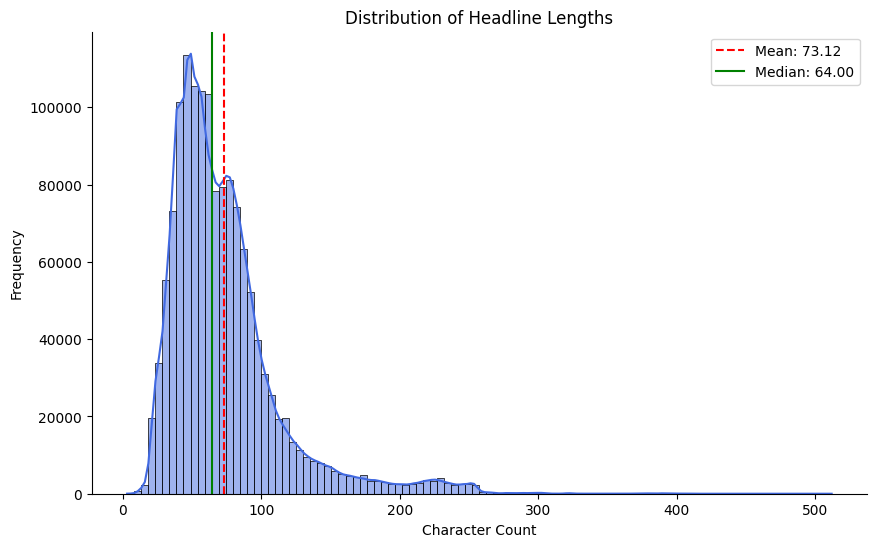

In [2]:
# Standard data science libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# yfinance  — free library to download stock price history
import yfinance as yf

# VADER    — sentiment analyser built for short financial/social media text
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# scipy    — for the Pearson correlation test
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load the data
df = pd.read_csv("C:/Users/nemsa/News-Sentiment-Analysis/data/raw/raw_analyst_ratings.csv")

# Task: Obtain basic statistics for textual lengths
df['headline_len'] = df['headline'].str.len()
print(df['headline_len'].describe())

# Plot the frequency distribution graph
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=100, kde=True, color='royalblue')
plt.axvline(df['headline_len'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_len"].mean():.2f}')
plt.axvline(df['headline_len'].median(), color='green', linestyle='-', label=f'Median: {df["headline_len"].median():.2f}')

plt.title('Distribution of Headline Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

What does this mean?

1. The "Typical" Headline

    * Mean (~73 chars): the average headline is about the length of a short sentence or a long tweet.

    * Median (50% mark at 64 chars): Since the mean (73) is higher than the median (64), the data is positively skewed. This means the dataset has a "long tail" of very long headlines pulling the average up.

2. The Spread (Variation)

    * Standard Deviation (~40): This is quite high relative to the mean. It tells us that headlines aren't all "roughly the same"—they vary quite a bit from the average.

    * The Range: The dataset has everything from tiny 3-character snippets (just stock tickers like "AAPL") to a massive 512-character headline (which is practically a full paragraph).

3. Outlier Check

    The Max (512): A 512-character headline is extremely unusual for financial news. These very long headlines might contain extra "noise" or multiple sentences and might affect future analysis.

In [3]:
# Task: Count articles per publisher
publisher_counts = df['publisher'].value_counts()
# Print the top 10 publishers
print(publisher_counts.head(10))

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


0     2020-06-05 10:30:54-04:00
1     2020-06-03 10:45:20-04:00
2     2020-05-26 04:30:07-04:00
3     2020-05-22 12:45:06-04:00
4     2020-05-22 11:38:59-04:00
5     2020-05-22 11:23:25-04:00
6     2020-05-22 09:36:20-04:00
7     2020-05-22 09:07:04-04:00
8     2020-05-22 08:37:59-04:00
9     2020-05-22 08:06:17-04:00
10          2020-05-22 00:00:00
11          2020-05-22 00:00:00
12          2020-05-21 00:00:00
13          2020-05-21 00:00:00
14          2020-05-21 00:00:00
Name: date, dtype: object
Number of unparseable dates: 0

Successfully converted samples:
                         date                   date_dt
0   2020-06-05 10:30:54-04:00 2020-06-05 14:30:54+00:00
1   2020-06-03 10:45:20-04:00 2020-06-03 14:45:20+00:00
2   2020-05-26 04:30:07-04:00 2020-05-26 08:30:07+00:00
3   2020-05-22 12:45:06-04:00 2020-05-22 16:45:06+00:00
4   2020-05-22 11:38:59-04:00 2020-05-22 15:38:59+00:00
5   2020-05-22 11:23:25-04:00 2020-05-22 15:23:25+00:00
6   2020-05-22 09:36:20-04:00 2020-05-

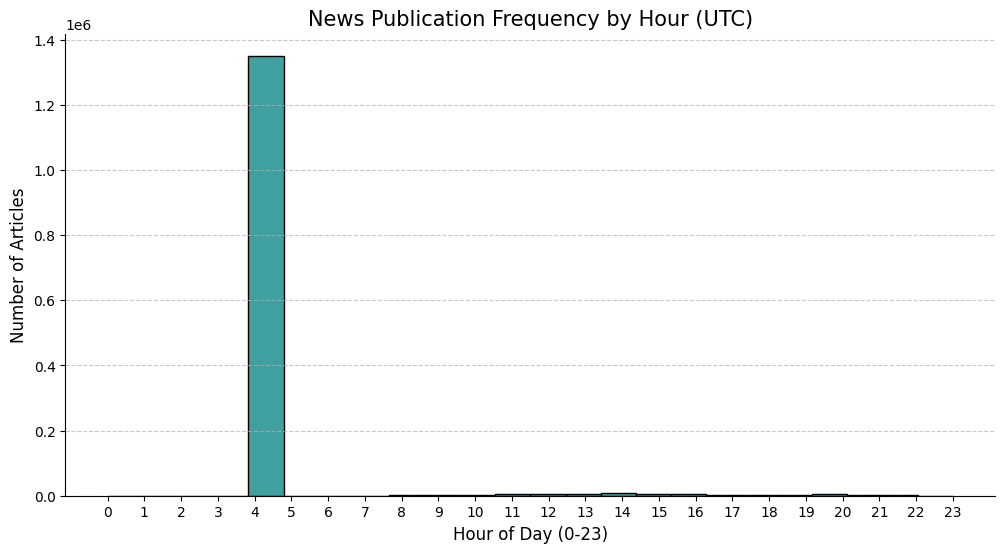

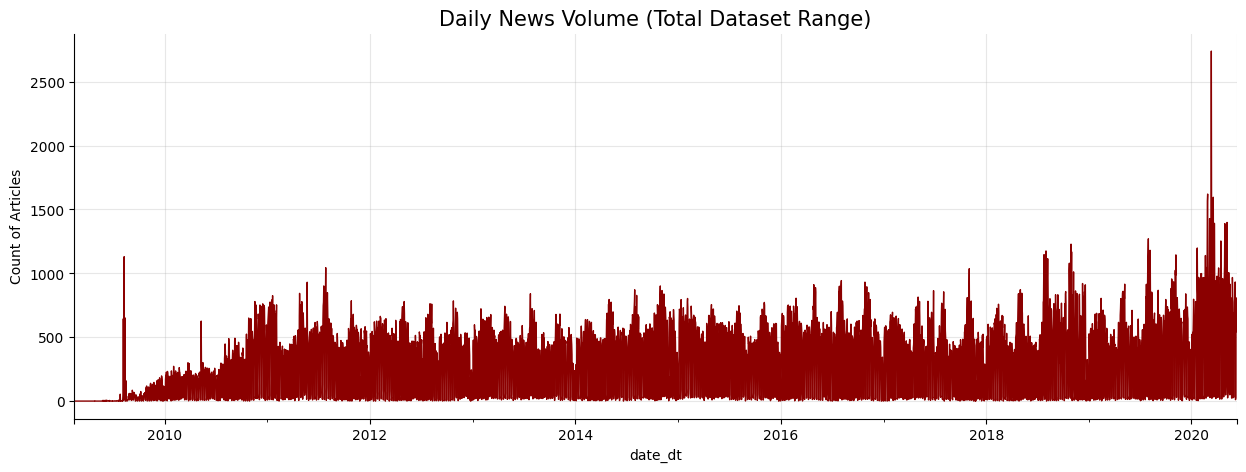

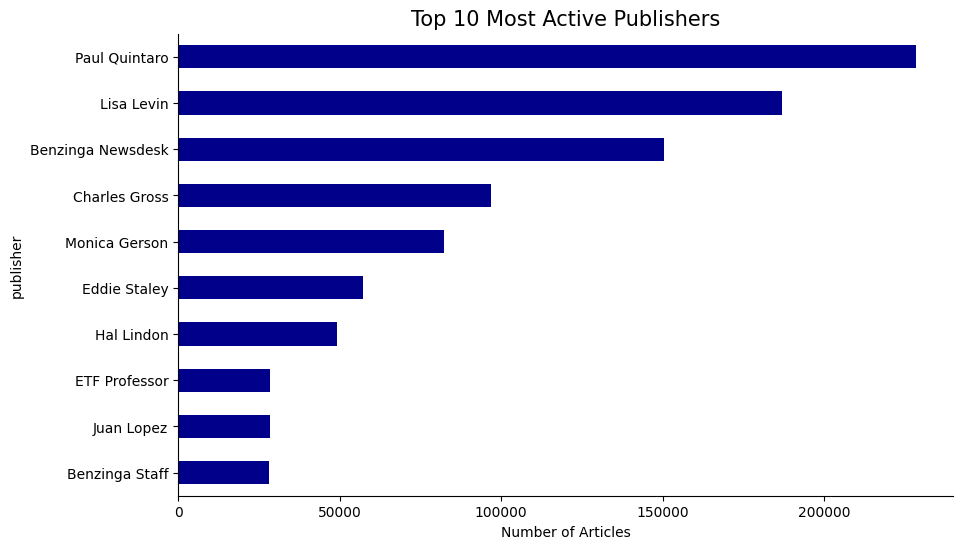

In [4]:
# Task: Analyze publication dates to identify trends over time

print(df['date'].head(15))  #check date format

# 1. Ensure the column is treated as strings and cleaned
df['date'] = df['date'].astype(str).str.strip()

# 2. Convert using ISO8601 format and force UTC
# This handles both the "-04:00" rows and the "00:00:00" rows
df['date_dt'] = pd.to_datetime(df['date'], format='ISO8601', utc=True, errors='coerce')

# 3. Verify the fix
print(f"Number of unparseable dates: {df['date_dt'].isna().sum()}")

# 4. If the count is 0 (or very low), peek at the results
if df['date_dt'].notna().any():
    print("\nSuccessfully converted samples:")
    print(df[['date', 'date_dt']].head(15))


# Extract the hour for publication frequency analysis
df['hour'] = df['date_dt'].dt.hour

# Plot 1: News Volume by Hour
plt.figure(figsize=(12, 6))
sns.histplot(df['hour'], bins=24, kde=False, color='teal', edgecolor='black')
plt.title('News Publication Frequency by Hour (UTC)', fontsize=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot 2: Daily News Volume
# Group by day
daily_news = df.resample('D', on='date_dt').size()

plt.figure(figsize=(15, 5))
daily_news.plot(color='darkred', linewidth=1)
plt.title('Daily News Volume (Total Dataset Range)', fontsize=15)
plt.ylabel('Count of Articles')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Top Publishers chart
plt.figure(figsize=(10, 6))
df['publisher'].value_counts().head(10).plot(kind='barh', color='darkblue').invert_yaxis()
plt.title('Top 10 Most Active Publishers', fontsize=15)
plt.xlabel('Number of Articles')
plt.show()


1. Publication Frequency by Hour

    * Observation: The publication volume shows an extreme concentration at the start of the day.

    * Peak Time: There is a massive spike between 00:00 and 01:00 UTC, reaching approximately 1.35 million articles.

    * Distribution: The remainder of the day shows near-zero activity.

    * Insight: This suggests that a vast majority of the dataset uses a default timestamp of 00:00:00, likely indicating that the exact time of publication was not captured for these records, or they represent daily "summary" uploads.

2. Daily News Volume Trends (2010 - 2020+)

    * Observation: News volume was relatively stable for a decade before experiencing a dramatic surge.

    * Historical Baseline: From 2010 to 2020, article volume typically oscillated between 0 and 1,000 articles per day, with occasional spikes hitting the 1,200–1,300 range.

    * Major Surge: Post-2020, there is a significant "regime shift" where volume peaks above 2,500 articles per day.

    * Insight: This surge aligns with the increased market volatility and retail trading interest following the COVID-19 pandemic, resulting in a higher frequency of financial reporting and analysis.

3. Top Active Publishers

    * Observation: The dataset is heavily influenced by a small group of high-volume contributors.

    * Key Players: The chart confirms our earlier finding that individuals like Paul Quintaro and Lisa Levin, along with the Benzinga Newsdesk, are the primary drivers of content.

    * Insight: Since the top 10 publishers account for a large portion of the total volume, any sentiment analysis performed later should consider whether these specific authors have unique writing styles or "biases" that could influence the overall results.

Top 10 Recurring Themes (Bigrams):
52 week: 51006
price target: 47274
stocks moving: 40044
mid day: 37324
market update: 33101
earnings scheduled: 32055
initiates coverage: 28993
pre market: 28393
raises pt: 27213
companies trading: 23170


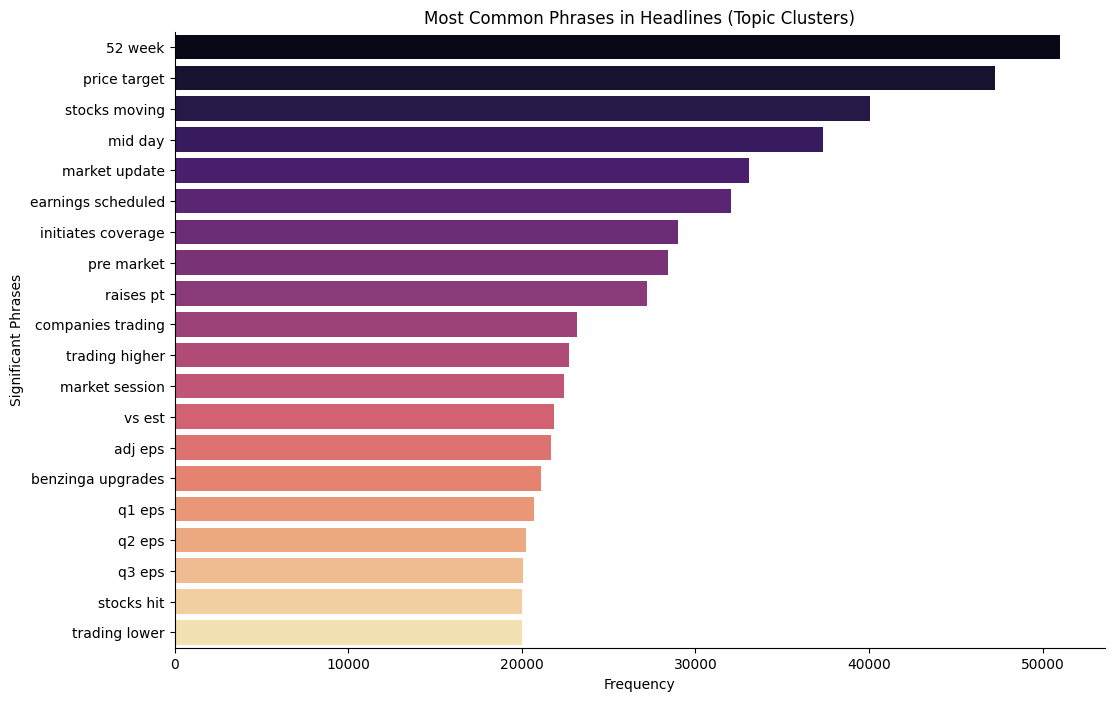

In [5]:
# Task: Text Analysis (Topic Modeling)

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Initialize CountVectorizer to look for 2-word phrases (bigrams)
# This will catch "price target", "earnings report", etc.
vec = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)

# 2. Fit and transform the headlines
bag_of_words = vec.fit_transform(df['headline'].dropna())

# 3. Get the counts
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

# 4. Display the top themes
print("Top 10 Recurring Themes (Bigrams):")
for word, freq in words_freq[:10]:
    print(f"{word}: {freq}")


# 5. Convert to DataFrame for easy plotting
df_words = pd.DataFrame(words_freq, columns=['Phrase', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Phrase', data=df_words.head(20), palette='magma')
plt.title('Most Common Phrases in Headlines (Topic Clusters)')
plt.xlabel('Frequency')
plt.ylabel('Significant Phrases')
plt.show()

1. Common Phrases (Bigram Analysis)

    * Using CountVectorizer, I extracted the most frequent two-word phrases (bigrams) to identify specific market events.
    
    * Insight: The prevalence of "price target" and "raises pt" suggests that a significant portion of this dataset is comprised of analyst rating changes, which are strong indicators of market sentiment.

In [6]:
from sklearn.decomposition import LatentDirichletAllocation

# Use a sample for speed
sample_df = df['headline'].dropna().sample(50000, random_state=42)

# Create the vectorizer
vec_lda = CountVectorizer(stop_words='english', max_features=1000)
data_vectorized = vec_lda.fit_transform(sample_df)

# Initialize LDA with 5 topics
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(data_vectorized)

# Function to print top words in topics
def print_topics(model, vectorizer, n_top_words):
    words = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic #{topic_idx + 1}:")
        print([words[i] for i in topic.argsort()[:-n_top_words - 1:-1]])

print_topics(lda_model, vec_lda, 7)


Topic #1:
['pt', 'buy', 'price', 'target', 'raises', 'maintains', '00']

Topic #2:
['benzinga', 'says', 'stock', 'announces', 'share', 'watch', 'downgrades']

Topic #3:
['vs', 'est', 'eps', 'reports', 'sales', 'estimate', 'q2']

Topic #4:
['shares', 'earnings', 'update', 'market', 'trading', 'higher', 'mid']

Topic #5:
['stocks', 'market', 'week', 'new', 'session', 'moving', '52']


2. Topic Modeling (LDA)

    * I applied Latent Dirichlet Allocation (LDA) to cluster the headlines into five distinct latent topics. This allows me to see the "pillars" of news covered by these publishers.

* Topic #1: Analyst Actions & Sentiment

    * Keywords: pt, buy, price, target, raises, maintains

    * Description: This topic captures Wall Street's opinion on stock valuations. It focuses on price target adjustments and "Buy/Hold/Sell" recommendations.

* Topic #2: Newsroom & Corporate Alerts

    * Keywords: benzinga, says, stock, announces, watch, downgrades

    * Description: This represents the core news feed—breaking alerts, corporate announcements, and specific stock "watchlists" curated by the Benzinga newsdesk.

* Topic #3: Financial Performance (Earnings)

    * Keywords: vs, est, eps, reports, sales, estimate, q2

    * Description: This is the most "data-heavy" topic. It focuses on quarterly earnings results, comparing actual Earnings Per Share (EPS) and Sales against analyst expectations.

* Topic #4: Market Momentum & Trading

    * Keywords: shares, earnings, update, market, trading, higher, mid

    * Description: This topic tracks how stocks are trading in real-time—whether they are moving higher or lower following an update.

* Topic #5: Technical Milestones & Market Sessions

    * Keywords: stocks, market, week, new, session, moving, 52

    * Description: This captures broader market trends, such as stocks hitting new 52-week highs/lows or general session summaries.

In [7]:
# Check if any publishers contain '@'
emails = df[df['publisher'].str.contains('@', na=False)]['publisher'].unique()

if len(emails) > 0:
    print(f"Found {len(emails)} email-based publishers. Extracting domains...")
    # Extract domain (part after @)
    df['publisher_domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')
    print(df['publisher_domain'].value_counts().head())
else:
    print("No email-based publishers found in the dataset. Requirement addressed.")

Found 18 email-based publishers. Extracting domains...
publisher_domain
benzinga.com      7937
gmail.com          139
andyswan.com         5
investdiva.com       2
tothetick.com        2
Name: count, dtype: int64


* Findings:

    * Organizational Dominance: Out of the records using email addresses as identifiers, benzinga.com is the overwhelming leader with 7,937 articles. This suggests that a large portion of the "unattributed" news is actually generated by Benzinga’s internal staff or automated systems.

    * External Contributions: I identified a small footprint of external contributors using domains such as:

        * gmail.com (139 articles) - likely independent or freelance contributors.

        * andyswan.com, investdiva.com, and tothetick.com - indicating syndicated content or guest analysis from niche financial platforms.

* Conclusion:
The publisher landscape is highly centralized. The content is driven primarily by a few high-output individuals and Benzinga's internal newsroom. This centralization ensures a consistent reporting style across the 1.4 million headlines, which will be beneficial for the consistency of our upcoming sentiment analysis.